<a href="https://colab.research.google.com/github/marrihruthika28/Machine_Learning/blob/main/Diabetes_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
data = pd.read_csv("diabetes.csv")

# Display the first 5 rows
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
print("Dataset Shape:", data.shape)
print("\nColumn Names:")
print(data.columns)

print("\nDataset Information:")
data.info()

Dataset Shape: (768, 9)

Column Names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
print(data["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [4]:
# Separate input features (X) and target/output (y)

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Input features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target:
Outcome


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [6]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions on the test data
lr_prediction = logistic_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_accuracy = accuracy_score(y_test, lr_prediction)
lr_precision = precision_score(y_test, lr_prediction)
lr_recall = recall_score(y_test, lr_prediction)
lr_f1 = f1_score(y_test, lr_prediction)

print("LOGISTIC REGRESSION RESULTS")
print("----------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))

LOGISTIC REGRESSION RESULTS
----------------------------
Accuracy : 0.7143
Precision: 0.6087
Recall   : 0.5185
F1 Score : 0.56


In [8]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions on the test data
rf_prediction = random_forest_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [9]:
rf_accuracy = accuracy_score(y_test, rf_prediction)
rf_precision = precision_score(y_test, rf_prediction)
rf_recall = recall_score(y_test, rf_prediction)
rf_f1 = f1_score(y_test, rf_prediction)

print("RANDOM FOREST RESULTS")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

RANDOM FOREST RESULTS
---------------------
Accuracy : 0.7597
Precision: 0.6809
Recall   : 0.5926
F1 Score : 0.6337


In [10]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation for Logistic Regression
lr_cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

# 5-fold cross-validation for Random Forest
rf_cv_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("5-FOLD CROSS-VALIDATION RESULTS")
print("--------------------------------")
print("Logistic Regression scores:", lr_cv_scores)
print("Logistic Regression mean accuracy:",
      round(lr_cv_scores.mean(), 4))

print("\nRandom Forest scores:", rf_cv_scores)
print("Random Forest mean accuracy:",
      round(rf_cv_scores.mean(), 4))

5-FOLD CROSS-VALIDATION RESULTS
--------------------------------
Logistic Regression scores: [0.77272727 0.74675325 0.75324675 0.81045752 0.77777778]
Logistic Regression mean accuracy: 0.7722

Random Forest scores: [0.74025974 0.74675325 0.75974026 0.83660131 0.75163399]
Random Forest mean accuracy: 0.767


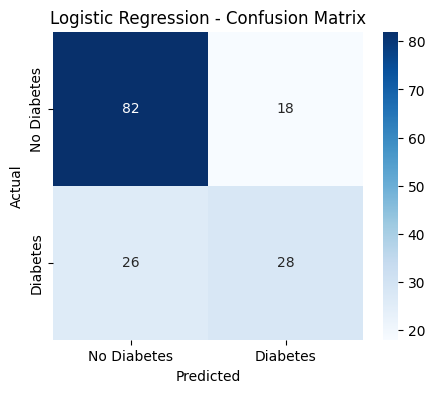

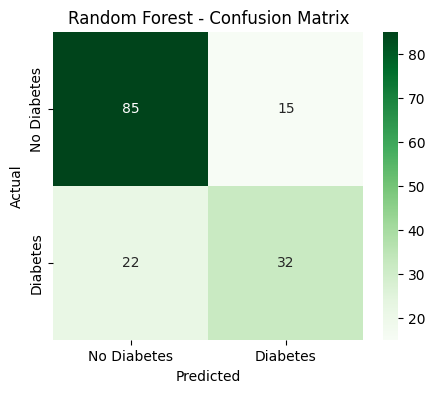

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrices
lr_cm = confusion_matrix(y_test, lr_prediction)
rf_cm = confusion_matrix(y_test, rf_prediction)

# Logistic Regression confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

FEATURE IMPORTANCE
------------------
Glucose                     0.276009
BMI                         0.159544
Age                         0.127248
DiabetesPedigreeFunction    0.126731
BloodPressure               0.085606
Pregnancies                 0.084456
Insulin                     0.072409
SkinThickness               0.067997
dtype: float64


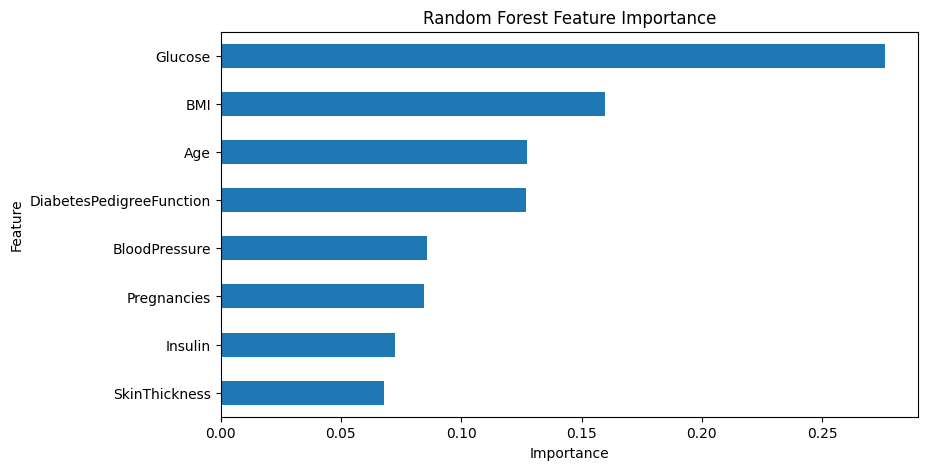

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Random Forest
feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("FEATURE IMPORTANCE")
print("------------------")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(9, 5))
feature_importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [13]:
# Compare both machine learning models

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Logistic Regression": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

print(comparison.to_string(index=False))

   Metric  Logistic Regression  Random Forest
 Accuracy             0.714286       0.759740
Precision             0.608696       0.680851
   Recall             0.518519       0.592593
 F1 Score             0.560000       0.633663


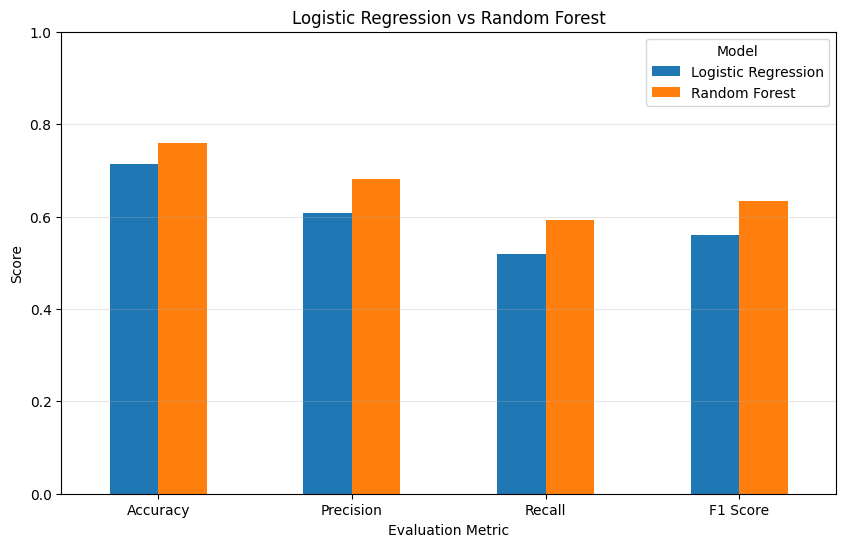

In [14]:
# Visual comparison of the two models

comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Logistic Regression vs Random Forest")
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [15]:
# Create a copy so the original dataset remains unchanged
clean_data = data.copy()

# Columns where zero values are not medically meaningful
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace zero values with NaN
import numpy as np

clean_data[zero_columns] = clean_data[zero_columns].replace(0, np.nan)

# Check how many missing values we now have
print("Missing values after replacing invalid zeros:")
print(clean_data.isnull().sum())

Missing values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [16]:
# Fill missing values using the median of each feature
for column in zero_columns:
    clean_data[column] = clean_data[column].fillna(
        clean_data[column].median()
    )

print("Missing values after preprocessing:")
print(clean_data.isnull().sum())

Missing values after preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [17]:
# Separate features and target from cleaned data

X_clean = clean_data.drop("Outcome", axis=1)
y_clean = clean_data["Outcome"]

print("Features:", X_clean.shape)
print("Target:", y_clean.shape)

Features: (768, 8)
Target: (768,)


In [18]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

print("Training data:", X_train_clean.shape)
print("Testing data:", X_test_clean.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [20]:
# Final Logistic Regression using cleaned and scaled data

final_lr_model = LogisticRegression(max_iter=1000)

final_lr_model.fit(X_train_scaled, y_train_clean)

final_lr_prediction = final_lr_model.predict(X_test_scaled)

print("Final Logistic Regression trained successfully!")

Final Logistic Regression trained successfully!


In [21]:
# Final Random Forest using cleaned data

final_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

final_rf_model.fit(X_train_clean, y_train_clean)

final_rf_prediction = final_rf_model.predict(X_test_clean)

print("Final Random Forest trained successfully!")

Final Random Forest trained successfully!


In [22]:
# Evaluate the final models

final_lr_accuracy = accuracy_score(y_test_clean, final_lr_prediction)
final_lr_precision = precision_score(y_test_clean, final_lr_prediction)
final_lr_recall = recall_score(y_test_clean, final_lr_prediction)
final_lr_f1 = f1_score(y_test_clean, final_lr_prediction)

final_rf_accuracy = accuracy_score(y_test_clean, final_rf_prediction)
final_rf_precision = precision_score(y_test_clean, final_rf_prediction)
final_rf_recall = recall_score(y_test_clean, final_rf_prediction)
final_rf_f1 = f1_score(y_test_clean, final_rf_prediction)

print("FINAL MODEL RESULTS")
print("===================")

print("\nLogistic Regression")
print("Accuracy :", round(final_lr_accuracy, 4))
print("Precision:", round(final_lr_precision, 4))
print("Recall   :", round(final_lr_recall, 4))
print("F1 Score :", round(final_lr_f1, 4))

print("\nRandom Forest")
print("Accuracy :", round(final_rf_accuracy, 4))
print("Precision:", round(final_rf_precision, 4))
print("Recall   :", round(final_rf_recall, 4))
print("F1 Score :", round(final_rf_f1, 4))

FINAL MODEL RESULTS

Logistic Regression
Accuracy : 0.7078
Precision: 0.6
Recall   : 0.5
F1 Score : 0.5455

Random Forest
Accuracy : 0.7792
Precision: 0.7273
Recall   : 0.5926
F1 Score : 0.6531


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Use the original dataset for a leakage-free evaluation
X_original = data.drop("Outcome", axis=1)
y_original = data["Outcome"]

# Convert physiologically invalid zero values to missing values
X_original = X_original.copy()
X_original[zero_columns] = X_original[zero_columns].replace(0, np.nan)

# Logistic Regression pipeline
lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Random Forest pipeline
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_cv_final = cross_val_score(
    lr_pipeline,
    X_original,
    y_original,
    cv=cv,
    scoring="accuracy"
)

rf_cv_final = cross_val_score(
    rf_pipeline,
    X_original,
    y_original,
    cv=cv,
    scoring="accuracy"
)

print("FINAL 5-FOLD CROSS-VALIDATION")
print("=============================")

print("\nLogistic Regression:")
print("Scores:", lr_cv_final)
print("Mean Accuracy:", round(lr_cv_final.mean(), 4))

print("\nRandom Forest:")
print("Scores:", rf_cv_final)
print("Mean Accuracy:", round(rf_cv_final.mean(), 4))

FINAL 5-FOLD CROSS-VALIDATION

Logistic Regression:
Scores: [0.77272727 0.7987013  0.77922078 0.75163399 0.75816993]
Mean Accuracy: 0.7721

Random Forest:
Scores: [0.77922078 0.75974026 0.78571429 0.73202614 0.73202614]
Mean Accuracy: 0.7577


In [24]:
from sklearn.model_selection import cross_validate

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

# Evaluate Logistic Regression
lr_results = cross_validate(
    lr_pipeline,
    X_original,
    y_original,
    cv=cv,
    scoring=scoring
)

# Evaluate Random Forest
rf_results = cross_validate(
    rf_pipeline,
    X_original,
    y_original,
    cv=cv,
    scoring=scoring
)

print("FINAL CROSS-VALIDATION METRICS")
print("==============================")

print("\nLOGISTIC REGRESSION")
print("Accuracy :", round(lr_results["test_accuracy"].mean(), 4))
print("Precision:", round(lr_results["test_precision"].mean(), 4))
print("Recall   :", round(lr_results["test_recall"].mean(), 4))
print("F1 Score :", round(lr_results["test_f1"].mean(), 4))

print("\nRANDOM FOREST")
print("Accuracy :", round(rf_results["test_accuracy"].mean(), 4))
print("Precision:", round(rf_results["test_precision"].mean(), 4))
print("Recall   :", round(rf_results["test_recall"].mean(), 4))
print("F1 Score :", round(rf_results["test_f1"].mean(), 4))

FINAL CROSS-VALIDATION METRICS

LOGISTIC REGRESSION
Accuracy : 0.7721
Precision: 0.7261
Recall   : 0.5711
F1 Score : 0.6358

RANDOM FOREST
Accuracy : 0.7577
Precision: 0.6769
Recall   : 0.5894
F1 Score : 0.6294


In [25]:
import pandas as pd
import numpy as np

def predict_diabetes_risk(
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
):
    # Create patient data in the same feature order as training
    patient = pd.DataFrame([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    ]], columns=X_original.columns)

    # Replace medically invalid zero values with NaN
    patient[zero_columns] = patient[zero_columns].replace(0, np.nan)

    # Use the trained Logistic Regression pipeline
    prediction = lr_pipeline.fit(X_original, y_original).predict(patient)
    probability = lr_pipeline.predict_proba(patient)[0][1]

    if prediction[0] == 1:
        result = "Higher Predicted Diabetes Risk"
    else:
        result = "Lower Predicted Diabetes Risk"

    print("====================================")
    print("       DIABETES RISK PREDICTOR")
    print("====================================")
    print("Prediction :", result)
    print("Risk Probability:", round(probability * 100, 2), "%")
    print("====================================")

In [26]:
predict_diabetes_risk(
    pregnancies=2,
    glucose=148,
    blood_pressure=72,
    skin_thickness=35,
    insulin=0,
    bmi=33.6,
    diabetes_pedigree=0.627,
    age=50
)

       DIABETES RISK PREDICTOR
Prediction : Higher Predicted Diabetes Risk
Risk Probability: 59.89 %


In [27]:
# Train the final Logistic Regression pipeline once

final_model = lr_pipeline.fit(X_original, y_original)

print("Final model trained and ready for predictions!")

Final model trained and ready for predictions!


In [28]:
def predict_diabetes(
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
):
    # Create patient data in the correct feature order
    patient = pd.DataFrame([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    ]], columns=X_original.columns)

    # Replace invalid zero values
    patient[zero_columns] = patient[zero_columns].replace(0, np.nan)

    # Predict using the already-trained model
    prediction = final_model.predict(patient)[0]
    probability = final_model.predict_proba(patient)[0][1]

    if prediction == 1:
        result = "Higher Predicted Diabetes Risk"
    else:
        result = "Lower Predicted Diabetes Risk"

    return result, probability

In [29]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create input fields
pregnancies_input = widgets.IntText(value=1, description="Pregnancies:")
glucose_input = widgets.IntText(value=120, description="Glucose:")
bp_input = widgets.IntText(value=70, description="Blood Pressure:")
skin_input = widgets.IntText(value=20, description="Skin Thickness:")
insulin_input = widgets.IntText(value=80, description="Insulin:")
bmi_input = widgets.FloatText(value=25.0, description="BMI:")
pedigree_input = widgets.FloatText(value=0.5, description="Pedigree:")
age_input = widgets.IntText(value=30, description="Age:")

predict_button = widgets.Button(
    description="PREDICT RISK",
    button_style="primary"
)

output = widgets.Output()


def on_predict_clicked(button):
    with output:
        clear_output()

        # Dataset-based validation
        ranges = {
            "Pregnancies": (0, data["Pregnancies"].max()),
            "Glucose": (1, data["Glucose"].max()),
            "Blood Pressure": (1, data["BloodPressure"].max()),
            "Skin Thickness": (1, data["SkinThickness"].max()),
            "Insulin": (1, data["Insulin"].max()),
            "BMI": (1, data["BMI"].max()),
            "Pedigree": (
                data["DiabetesPedigreeFunction"].min(),
                data["DiabetesPedigreeFunction"].max()
            ),
           "Age": (data["Age"].min(), data["Age"].max())
        }

        values = {
            "Pregnancies": pregnancies_input.value,
            "Glucose": glucose_input.value,
            "Blood Pressure": bp_input.value,
            "Skin Thickness": skin_input.value,
            "Insulin": insulin_input.value,
            "BMI": bmi_input.value,
            "Pedigree": pedigree_input.value,
            "Age": age_input.value
        }

        # Check values
        for name, value in values.items():
            minimum, maximum = ranges[name]

            if value < minimum or value > maximum:
                print(f"Invalid {name} value.")
                print(f"Please enter a value between {minimum:.2f} and {maximum:.2f}.")
                return

        # Make prediction
        result, probability = predict_diabetes(
            pregnancies_input.value,
            glucose_input.value,
            bp_input.value,
            skin_input.value,
            insulin_input.value,
            bmi_input.value,
            pedigree_input.value,
            age_input.value
        )

        print("=" * 45)
        print("       DIABETES RISK PREDICTOR")
        print("=" * 45)
        print()
        print("Prediction:", result)
        print("Risk Probability:", round(probability * 100, 2), "%")
        print()
        print("Note: This is a machine-learning risk")
        print("prediction and not a medical diagnosis.")
        print("=" * 45)


predict_button.on_click(on_predict_clicked)

display(
    pregnancies_input,
    glucose_input,
    bp_input,
    skin_input,
    insulin_input,
    bmi_input,
    pedigree_input,
    age_input,
    predict_button,
    output
)

IntText(value=1, description='Pregnancies:')

IntText(value=120, description='Glucose:')

IntText(value=70, description='Blood Pressure:')

IntText(value=20, description='Skin Thickness:')

IntText(value=80, description='Insulin:')

FloatText(value=25.0, description='BMI:')

FloatText(value=0.5, description='Pedigree:')

IntText(value=30, description='Age:')

Button(button_style='primary', description='PREDICT RISK', style=ButtonStyle())

Output()

In [30]:
!pip install gradio -q

In [31]:
import gradio as gr

def gradio_predict(
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
):
    # Dataset-based validation
    ranges = {
        "Pregnancies": (0, data["Pregnancies"].max()),
        "Glucose": (1, data["Glucose"].max()),
        "Blood Pressure": (1, data["BloodPressure"].max()),
        "Skin Thickness": (1, data["SkinThickness"].max()),
        "Insulin": (1, data["Insulin"].max()),
        "BMI": (1, data["BMI"].max()),
        "Pedigree": (
            data["DiabetesPedigreeFunction"].min(),
            data["DiabetesPedigreeFunction"].max()
        ),
        "Age": (data["Age"].min(), data["Age"].max())
    }

    values = {
        "Pregnancies": pregnancies,
        "Glucose": glucose,
        "Blood Pressure": blood_pressure,
        "Skin Thickness": skin_thickness,
        "Insulin": insulin,
        "BMI": bmi,
        "Pedigree": diabetes_pedigree,
        "Age": age
    }

    # Validate inputs
    for name, value in values.items():
        minimum, maximum = ranges[name]

        if value < minimum or value > maximum:
            return (
                f"Invalid {name} value. "
                f"Please enter a value between {minimum:.2f} and {maximum:.2f}.",
                ""
            )

    # Make prediction using your existing trained model
    result, probability = predict_diabetes(
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    )

    probability_percent = probability * 100

    return (
        result,
        f"{probability_percent:.2f}%"
    )

In [35]:
import gradio as gr

# ============================================================
# MINIMAL PROFESSIONAL LIGHT UI
# Diabetes Risk Prediction
# ============================================================

custom_css = """

/* =========================================================
   GLOBAL PAGE
   ========================================================= */

html,
body {
    background: #ffffff !important;
}

body {
    margin: 0 !important;
    font-family: Arial, Helvetica, sans-serif !important;
}

.gradio-container {
    background: #ffffff !important;
    max-width: 1120px !important;
    margin: 0 auto !important;
    padding: 0 32px 40px 32px !important;
}


/* =========================================================
   REMOVE DEFAULT DARK GRADIO BACKGROUNDS
   ========================================================= */

.gradio-container,
.gradio-container > *,
.block,
.block.gr-box,
.gr-box,
.gr-panel,
.gr-group,
.form,
.wrap {
    background-color: #ffffff !important;
}


/* =========================================================
   HEADER
   ========================================================= */

.header {
    background: #ffffff !important;
    padding: 42px 5px 28px 5px;
    margin-bottom: 35px;
    border-bottom: 1px solid #e5e7eb;
}

.header h1 {
    color: #111827 !important;
    font-size: 34px !important;
    font-weight: 700 !important;
    margin: 0 0 10px 0 !important;
    letter-spacing: -0.5px;
}

.header p {
    color: #6b7280 !important;
    font-size: 15px !important;
    margin: 0 !important;
    line-height: 1.6;
}


/* =========================================================
   SECTION TITLES
   ========================================================= */

.section-title {
    color: #111827 !important;
    font-size: 20px;
    font-weight: 700;
    margin-bottom: 6px;
}

.section-subtitle {
    color: #6b7280 !important;
    font-size: 14px;
    margin-bottom: 18px;
}


/* =========================================================
   CARDS
   ========================================================= */

.input-card,
.result-card {

    background: #ffffff !important;

    border: 1px solid #e5e7eb !important;

    border-radius: 14px !important;

    padding: 24px !important;

    box-shadow: 0 2px 8px rgba(15, 23, 42, 0.04) !important;
}


/* =========================================================
   INPUT LABELS
   ========================================================= */

label,
label span {

    color: #374151 !important;

    background: transparent !important;

    font-size: 14px !important;

    font-weight: 600 !important;
}


/* =========================================================
   INPUT BOXES
   ========================================================= */

input,
textarea {

    background: #ffffff !important;

    color: #111827 !important;

    border: 1px solid #d1d5db !important;

    border-radius: 8px !important;

    font-size: 14px !important;
}


input {
    min-height: 42px !important;
}


input:focus,
textarea:focus {

    border-color: #2563eb !important;

    box-shadow: 0 0 0 2px rgba(37, 99, 235, 0.08) !important;
}


/* =========================================================
   PREDICT BUTTON
   ========================================================= */

.predict-btn {

    background: #2563eb !important;

    color: #ffffff !important;

    border: none !important;

    border-radius: 8px !important;

    height: 46px !important;

    font-size: 15px !important;

    font-weight: 600 !important;

    margin-top: 10px !important;
}

.predict-btn:hover {

    background: #1d4ed8 !important;
}


/* =========================================================
   RESET BUTTON
   ========================================================= */

.reset-btn {

    background: #ffffff !important;

    color: #374151 !important;

    border: 1px solid #d1d5db !important;

    border-radius: 8px !important;

    height: 46px !important;

    font-size: 15px !important;

    font-weight: 500 !important;

    margin-top: 10px !important;
}

.reset-btn:hover {

    background: #f9fafb !important;
}


/* =========================================================
   OUTPUT BOXES
   ========================================================= */

.output-box textarea {

    background: #ffffff !important;

    color: #111827 !important;

    border: 1px solid #d1d5db !important;

    border-radius: 8px !important;

    font-size: 15px !important;

    font-weight: 600 !important;
}


/* =========================================================
   INFORMATION BOX
   ========================================================= */

.info-box {

    background: #f8fafc !important;

    border: 1px solid #e5e7eb !important;

    border-radius: 10px !important;

    padding: 16px !important;

    margin-top: 20px !important;

    color: #64748b !important;

    font-size: 13px !important;

    line-height: 1.6 !important;
}

.info-box b {

    color: #374151 !important;
}


/* =========================================================
   DISCLAIMER
   ========================================================= */

.disclaimer {

    text-align: center;

    color: #9ca3af !important;

    font-size: 12px;

    line-height: 1.6;

    padding: 30px 20px 10px 20px;

    margin-top: 10px;
}


/* =========================================================
   REMOVE GRADIO FOOTER
   ========================================================= */

footer {
    display: none !important;
}


/* =========================================================
   RESPONSIVE MOBILE VIEW
   ========================================================= */

@media (max-width: 800px) {

    .gradio-container {
        padding: 0 18px 30px 18px !important;
    }

    .header {
        padding: 30px 5px 22px 5px;
    }

    .header h1 {
        font-size: 28px !important;
    }

}


/* =========================================================
   REMOVE EXTRA BACKGROUND COLORS FROM FORM ELEMENTS
   ========================================================= */

[data-testid="block-info"],
[data-testid="form"],
[data-testid="panel"] {

    background: #ffffff !important;
}


/* =========================================================
   BUTTON TEXT
   ========================================================= */

button {

    font-family: Arial, Helvetica, sans-serif !important;

}


/* =========================================================
   HIDE DEFAULT FLAGGING ELEMENTS
   ========================================================= */

.flagging,
.flagging-container {

    display: none !important;
}

"""


# ============================================================
# INPUT COMPONENTS
# ============================================================

pregnancies = gr.Number(
    label="Pregnancies",
    value=1,
    precision=0
)

glucose = gr.Number(
    label="Glucose Level (mg/dL)",
    value=120,
    precision=0
)

blood_pressure = gr.Number(
    label="Blood Pressure (mm Hg)",
    value=70,
    precision=0
)

skin_thickness = gr.Number(
    label="Skin Thickness (mm)",
    value=20,
    precision=0
)

insulin = gr.Number(
    label="Insulin (μU/mL)",
    value=80,
    precision=0
)

bmi = gr.Number(
    label="BMI",
    value=25.0
)

diabetes_pedigree = gr.Number(
    label="Diabetes Pedigree Function",
    value=0.5
)

age = gr.Number(
    label="Age",
    value=30,
    precision=0
)


# ============================================================
# OUTPUT COMPONENTS
# ============================================================

prediction = gr.Textbox(
    label="Prediction",
    placeholder="Prediction will appear here",
    elem_classes="output-box"
)

risk_probability = gr.Textbox(
    label="Risk Probability",
    placeholder="Risk probability will appear here",
    elem_classes="output-box"
)


# ============================================================
# BUILD APPLICATION
# ============================================================

with gr.Blocks(
    theme=gr.themes.Base(
        primary_hue="blue",
        secondary_hue="blue",
        neutral_hue="slate"
    ),
    css=custom_css
) as demo:


    # ========================================================
    # HEADER
    # ========================================================

    gr.HTML("""
    <div class="header">

        <h1>Diabetes Risk Prediction</h1>

        <p>
            Machine learning based assessment using clinical
            and demographic health parameters.
        </p>

    </div>
    """)


    # ========================================================
    # MAIN CONTENT
    # ========================================================

    with gr.Row(equal_height=False):


        # ====================================================
        # LEFT SIDE - PATIENT INFORMATION
        # ====================================================

        with gr.Column(scale=1):

            gr.HTML("""
            <div class="section-title">
                Patient Information
            </div>

            <div class="section-subtitle">
                Enter the required health parameters below.
            </div>
            """)


            with gr.Group(elem_classes="input-card"):

                pregnancies.render()

                glucose.render()

                blood_pressure.render()

                skin_thickness.render()

                insulin.render()

                bmi.render()

                diabetes_pedigree.render()

                age.render()


            # BUTTONS

            with gr.Row():

                reset_btn = gr.Button(
                    "Reset",
                    elem_classes="reset-btn"
                )

                predict_btn = gr.Button(
                    "Predict Risk",
                    elem_classes="predict-btn"
                )


        # ====================================================
        # RIGHT SIDE - RESULTS
        # ====================================================

        with gr.Column(scale=1):

            gr.HTML("""
            <div class="section-title">
                Prediction Result
            </div>

            <div class="section-subtitle">
                Model-generated diabetes risk assessment.
            </div>
            """)


            with gr.Group(elem_classes="result-card"):

                prediction.render()

                risk_probability.render()


                # INFORMATION

                gr.HTML("""
                <div class="info-box">

                    <b>How it works</b><br><br>

                    The machine learning model analyzes the
                    entered health parameters and estimates
                    diabetes risk based on patterns learned
                    from the Pima Indians Diabetes Dataset.

                </div>
                """)


    # ========================================================
    # DISCLAIMER
    # ========================================================

    gr.HTML("""
    <div class="disclaimer">

        This application is intended for educational and
        research purposes only. It is not a medical diagnosis
        or a substitute for professional medical advice.

    </div>
    """)


    # ========================================================
    # PREDICTION BUTTON
    # ========================================================

    predict_btn.click(

        fn=gradio_predict,

        inputs=[
            pregnancies,
            glucose,
            blood_pressure,
            skin_thickness,
            insulin,
            bmi,
            diabetes_pedigree,
            age
        ],

        outputs=[
            prediction,
            risk_probability
        ]

    )


    # ========================================================
    # RESET BUTTON
    # ========================================================

    reset_btn.click(

        fn=lambda: [
            1,
            120,
            70,
            20,
            80,
            25.0,
            0.5,
            30,
            "",
            ""
        ],

        inputs=[],

        outputs=[
            pregnancies,
            glucose,
            blood_pressure,
            skin_thickness,
            insulin,
            bmi,
            diabetes_pedigree,
            age,
            prediction,
            risk_probability
        ]

    )


# ============================================================
# LAUNCH
# ============================================================

demo.launch()

/tmp/ipykernel_731/711959428.py:428: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c34ccdae66c00ff44b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
